# Naive Bayes Model

In [153]:

import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [154]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [155]:
# Reusable project functions
from src.features import get_tfidf_features
from src.evaluate import evaluate_model

In [156]:
pd.set_option("display.max_colwidth", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [157]:

# File paths 

TRAIN_PATH = "../datasets/processed/train_split.csv"
VAL_PATH = "../datasets/processed/val_split.csv"
TEST_PATH = "../datasets/processed/test_split.csv"

MODEL_DIR = "../saved_models"

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "naive_bayes.pkl"
)

VECTORIZER_PATH = os.path.join(
    MODEL_DIR,
    "naive_bayes_tfidf_vectorizer.pkl"
)

RESULTS_DIR = "../results"

RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "model_comparison.csv"
)

CONFUSION_MATRIX_DIR = os.path.join(
    RESULTS_DIR,
    "confusion_matrices"
)


In [158]:

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CONFUSION_MATRIX_DIR, exist_ok=True)

print("File paths are ready!")
print("Model directory:", MODEL_DIR)
print("Results directory:", RESULTS_DIR)
print("Confusion matrix directory:", CONFUSION_MATRIX_DIR)

File paths are ready!
Model directory: ../saved_models
Results directory: ../results
Confusion matrix directory: ../results\confusion_matrices


In [159]:

# Load datasets

try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully!\n")

    print("Training set:", train_df.shape)
    print("Validation set:", val_df.shape)
    print("Test set:", test_df.shape)

except FileNotFoundError as e:
    print("Error: Could not find one of the dataset files.")
    print("Please check the file paths.")
    print(e)

Datasets loaded successfully!

Training set: (4288, 2)
Validation set: (920, 2)
Test set: (920, 2)


In [160]:
required_columns = ["text", "label"]

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print(f"{name} set is missing: {missing_columns}")
    else:
        print(f"{name} set: OK")

print("\nExample training data:")
display(train_df[["text", "label"]].head())

Training set: OK
Validation set: OK
Test set: OK

Example training data:


,text,label
0,mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata...,1
1,chinta kt kro beta madhur tmko tmri bhakti ke lie rajya sabha mn entry mil jaegi bo bhi rape ke ...,0
2,modi ka to pata nahi par aj vi delhi me rape ro raha hai tum log sirf modi modi modi ka mala jap...,0
3,teri gaand ka business,1
4,aur hum par terrorism ka label lagane wale duniya ache tarah jante hai aur tu bhe india is the m...,1


In [161]:
# tf-idf feature extraction

X_train, X_val, vectorizer = get_tfidf_features(
    train_texts=train_df["text"],
    test_texts=val_df["text"],
    ngram_range=(1, 2),
    max_features=20000
)

y_train = train_df["label"]
y_val = val_df["label"]

print("TF-IDF feature extraction completed!\n")

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)

TF-IDF feature extraction completed!

Training feature shape: (4288, 20000)
Validation feature shape: (920, 20000)


In [162]:
# Train Naive Bayes

model = MultinomialNB(alpha=0.5)

model.fit(X_train, y_train)

print("Multinomial Naive Bayes trained successfully!")

Multinomial Naive Bayes trained successfully!


In [163]:
print("Unique labels:", sorted(train_df["label"].unique()))
print("\nLabel distribution:")
print(train_df["label"].value_counts())

Unique labels: [0, 1]

Label distribution:
label
0    2503
1    1785
Name: count, dtype: int64


In [164]:
print("Model classes:", model.classes_)

Model classes: [0 1]


In [165]:
# Validation evaluation
val_predictions = model.predict(X_val)

val_results = evaluate_model(
    y_true=y_val,
    y_pred=val_predictions,
    model_name="Naive Bayes - Validation"
)

print("\nValidation Results:")
print(val_results)


Validation Results:
{'model': 'Naive Bayes - Validation', 'accuracy': 0.7086956521739131, 'precision': 0.8484848484848485, 'recall': 0.36553524804177545, 'f1': 0.5109489051094891}


In [166]:
# Sample predictions with probabilities

import re

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample_comments = [
    "mar ja tu",
    "bekwass hai tu bhai!",
    "kal milte hain, take care"
]

cleaned_comments = [
    basic_clean(comment)
    for comment in sample_comments
]

sample_features = vectorizer.transform(cleaned_comments)
sample_predictions = model.predict(sample_features)
sample_probabilities = model.predict_proba(sample_features)

In [167]:

print("Sample Predictions")
print("=" * 70)

for original_comment, cleaned_comment, prediction, probabilities in zip(
    sample_comments,
    cleaned_comments,
    sample_predictions,
    sample_probabilities
):
    
    probability_by_class = dict(zip(model.classes_, probabilities))

    not_offensive_probability = probability_by_class.get(0, 0.0)
    offensive_probability = probability_by_class.get(1, 0.0)

    label = (
        "CYBERBULLYING / OFFENSIVE"
        if prediction == 1
        else "NOT OFFENSIVE"
    )

    print(f"Original comment: {original_comment}")
    print(f"Cleaned comment:  {cleaned_comment}")
    print(f"Raw prediction:   {prediction}")
    print(f"Predicted label:  {label}")
    print(
        f"Probability - Not Offensive (0): "
        f"{not_offensive_probability:.4f}"
    )
    print(
        f"Probability - Offensive (1):     "
        f"{offensive_probability:.4f}"
    )
    print("-" * 70)

Sample Predictions
Original comment: mar ja tu
Cleaned comment:  mar ja tu
Raw prediction:   1
Predicted label:  CYBERBULLYING / OFFENSIVE
Probability - Not Offensive (0): 0.4112
Probability - Offensive (1):     0.5888
----------------------------------------------------------------------
Original comment: bekwass hai tu bhai!
Cleaned comment:  bekwass hai tu bhai
Raw prediction:   0
Predicted label:  NOT OFFENSIVE
Probability - Not Offensive (0): 0.8997
Probability - Offensive (1):     0.1003
----------------------------------------------------------------------
Original comment: kal milte hain, take care
Cleaned comment:  kal milte hain take care
Raw prediction:   0
Predicted label:  NOT OFFENSIVE
Probability - Not Offensive (0): 0.6625
Probability - Offensive (1):     0.3375
----------------------------------------------------------------------


In [168]:
# Check whether important words were learned by the model

words_to_check = [
    "tu","bekwass","mar","ja","bhai"
]

print("Training label distribution")
print(train_df["label"].value_counts())
print()

for word in words_to_check:
    is_in_vocabulary = word in vectorizer.vocabulary_

    matches = train_df[
        train_df["text"].astype(str).str.contains(
            rf"\b{re.escape(word)}\b",case=False,regex=True,na=False)
    ]

    print(f"Word: {word}")
    print(f"In TF-IDF vocabulary: {is_in_vocabulary}")
    print(f"Training occurrences: {len(matches)}")

    if not matches.empty:
        print("Label distribution:")
        print(matches["label"].value_counts())

    print("-" * 50)

Training label distribution
label
0    2503
1    1785
Name: count, dtype: int64

Word: tu
In TF-IDF vocabulary: True
Training occurrences: 546
Label distribution:
label
0    492
1     54
Name: count, dtype: int64
--------------------------------------------------
Word: bekwass
In TF-IDF vocabulary: False
Training occurrences: 0
--------------------------------------------------
Word: mar
In TF-IDF vocabulary: True
Training occurrences: 35
Label distribution:
label
1    21
0    14
Name: count, dtype: int64
--------------------------------------------------
Word: ja
In TF-IDF vocabulary: True
Training occurrences: 66
Label distribution:
label
0    39
1    27
Name: count, dtype: int64
--------------------------------------------------
Word: bhai
In TF-IDF vocabulary: True
Training occurrences: 344
Label distribution:
label
0    283
1     61
Name: count, dtype: int64
--------------------------------------------------


In [169]:
# Save the trained model and vectorizer

try:
    with open(MODEL_PATH, "wb") as file:
        pickle.dump(model, file)

    with open(VECTORIZER_PATH, "wb") as file:
        pickle.dump(vectorizer, file)

    print("Model saved successfully!")
    print(f"Model: {MODEL_PATH}")
    print(f"Vectorizer: {VECTORIZER_PATH}")

except Exception as e:
    print("Error while saving model:", e)

Model saved successfully!
Model: ../saved_models\naive_bayes.pkl
Vectorizer: ../saved_models\naive_bayes_tfidf_vectorizer.pkl


In [170]:
# Final test evaluation

X_test = vectorizer.transform(test_df["text"])

y_test = test_df["label"]

test_predictions = model.predict(X_test)


test_results = evaluate_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name="Naive Bayes - Test"
)

print("\nFinal Test Results:")
print(test_results)


Final Test Results:
{'model': 'Naive Bayes - Test', 'accuracy': 0.7130434782608696, 'precision': 0.8562874251497006, 'recall': 0.3733681462140992, 'f1': 0.52}


In [171]:

y_test_pred = model.predict(X_test)

print("Test predictions generated successfully!")
print("Number of predictions:", len(y_test_pred))
print("Number of actual labels:", len(y_test))

Test predictions generated successfully!
Number of predictions: 920
Number of actual labels: 920


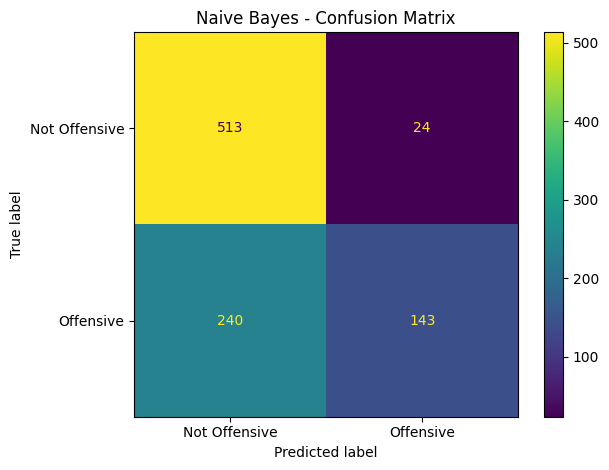

Confusion matrix saved to:
../results\confusion_matrices\naive_bayes.png


In [172]:
# Confusion Matrix for Naive Bayes

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Offensive", "Offensive"]
)

disp.plot()

plt.title("Naive Bayes - Confusion Matrix")
plt.tight_layout()

CONFUSION_MATRIX_PATH = os.path.join(
    CONFUSION_MATRIX_DIR,"naive_bayes.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(CONFUSION_MATRIX_PATH)

In [173]:
# Save Naive Bayes test results

def log_result(results_dict, results_path):
    results_row = pd.DataFrame([results_dict])

    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
        updated_results = pd.concat(
            [existing_results, results_row],
            ignore_index=True
        )
        
    else:
        updated_results = results_row

    # Save updated results
    updated_results.to_csv(
        results_path,
        index=False
    )
    print(f"Results saved to: {results_path}")

log_result(
    test_results,
    RESULTS_PATH
)

Results saved to: ../results\model_comparison.csv


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24512\2337438658.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  updated_results = pd.concat(


In [174]:
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    display(results_df)

else:
    print("No comparison results file found.")

,model,accuracy,precision,recall,f1
0,Naive Bayes - Test,0.713043,0.856287,0.373368,0.52
